### Create AnnData object for GSE25109 — Sato 2011 Lgr5⁺ ISC vs Paneth-cell microarray

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData (samples × genes) from 4 Agilent 2-channel microarray FE files at `LGR5_analysis_data/GSE25109/` (platform GPL4134). Sato 2011 design: FACS-sorted **Lgr5-EGFP+ ISCs** vs **CD24⁺ Paneth cells** from Lgr5-EGFP-IRES-CreERT2 mice, 2 replicates per population.

⚠️ **Per-GSM assignment is a best-guess by GSM order** — `GSM617045/6 = Lgr5-EGFP+`, `GSM617047/8 = CD24+ Paneth`. Verify against the GEO sample metadata (`https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE25109`) before relying on this AnnData. Note: in this study `lgr5_status='LGR5-'` is used for Paneth cells (= Lgr5-negative niche cells), with the cell_type column carrying `Paneth`. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §9).

### Import packages

In [1]:
import os, sys, glob
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, os.getcwd())
from utils.agilent_fe import load_agilent_study

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Per-sample metadata

In [2]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE25109'

# Match each GSM to its actual file (filenames carry a long Agilent run suffix)
SAMPLE_PATHS = {}
for gsm in ['GSM617045', 'GSM617046', 'GSM617047', 'GSM617048']:
    matches = glob.glob(os.path.join(DATA_DIR, f'{gsm}_*.txt.gz'))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected exactly one {gsm}_*.txt.gz in {DATA_DIR}, got {matches}')
    SAMPLE_PATHS[gsm] = matches[0]

SAMPLE_META = {
    'GSM617045': dict(sample='Lgr5+_ISC_rep1',  lgr5_status='LGR5+', lgr5_label_raw='Lgr5-EGFP+',  condition='Lgr5-EGFP+',  cell_type='Lgr5+ ISC', tissue='small intestine crypt', GSE='GSE25109', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM617046': dict(sample='Lgr5+_ISC_rep2',  lgr5_status='LGR5+', lgr5_label_raw='Lgr5-EGFP+',  condition='Lgr5-EGFP+',  cell_type='Lgr5+ ISC', tissue='small intestine crypt', GSE='GSE25109', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM617047': dict(sample='CD24+_Paneth_rep1', lgr5_status='LGR5-', lgr5_label_raw='CD24+ Paneth', condition='CD24+ Paneth', cell_type='Paneth',     tissue='small intestine crypt', GSE='GSE25109', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM617048': dict(sample='CD24+_Paneth_rep2', lgr5_status='LGR5-', lgr5_label_raw='CD24+ Paneth', condition='CD24+ Paneth', cell_type='Paneth',     tissue='small intestine crypt', GSE='GSE25109', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
}

### Parse and build AnnData

In [3]:
adata = load_agilent_study(SAMPLE_PATHS, SAMPLE_META, value_column='LogRatio', aggregate='mean')
for col in ['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'GSE', 'organism', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata

AnnData object with n_obs × n_vars = 4 × 27827
    obs: 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'GSE', 'organism', 'technology', 'assay_modality'
    var: 'n_probes'
    uns: 'agilent_value_column', 'agilent_aggregate', 'agilent_n_channels'

### Sanity check — Lgr5 / Defa / Lyz1 (Paneth markers)

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2074: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in [*adata.obs_keys(), adata.obs.index.name]:


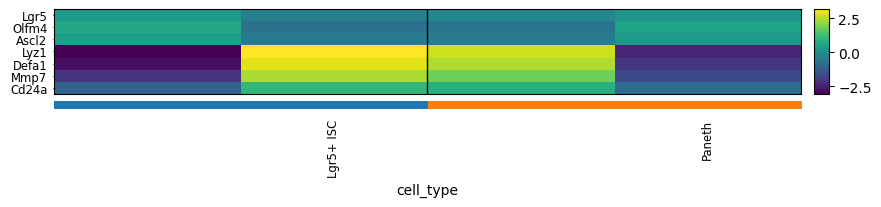

In [4]:
markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Lyz1', 'Defa1', 'Defa17', 'Mmp7', 'Cd24a'] if g in adata.var_names]
if markers:
    sc.pl.heatmap(adata, var_names=markers, groupby='cell_type', swap_axes=True, dendrogram=False)

### Save

In [5]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE25109'
adata.uns['publication'] = 'Sato T et al., Nature 469:415-418 (2011) — Paneth cells constitute the niche for Lgr5 stem cells in intestinal crypts'
adata.uns['genome_reference'] = 'GPL4134 — Agilent Whole Mouse Genome Microarray 4x44K v2'
adata.uns['source_files'] = sorted([os.path.basename(p) for p in SAMPLE_PATHS.values()] + ['GPL4134_old_annotations.txt.gz'])
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from 4 Agilent 2-channel FE files; LogRatio extracted; per-gene mean across probes; lgr5_status assigned by best-guess GSM order (verify against GEO metadata). | note: X holds log2(red/green) ratios per probe-aggregated gene, NOT raw counts. lgr5_status=LGR5- here means Paneth cells (Lgr5-negative niche), not Lgr5-low daughters.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE25109_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE25109_AM_07052026_233208_raw.h5ad (4, 27827)
